# Solar-wind paper statistics

Rebuild the paper statistics and figures without rerunning propagation. The propagated model comes from an exact SW reproduction parquet; the observed and recurrent series are restored from the cached spacecraft data without filling data gaps.

The paper comparisons are raw model versus observations, recurrent forecast versus observations, and the slow-wind-patched Earth model versus SWX. ICME exclusion includes the 12-hour tail; plotted physical ICME duration per Carrington rotation does not. Dst remains in the event export for ACE at Earth only and is not plotted.


In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Library").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "Library").exists(), "Run this notebook from the repository or Analysis directory"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from Library.SW.Stats import (
    export_icme_event_csv,
    export_sw_forecast_cr_stats_csv,
    export_sw_forecast_stats_csv,
    restore_observed_and_recurrent_series,
)
from Library.SW.Visualization import (
    PREDICT_RAW_COLUMN,
    export_solar_wind_plot,
    plot_cr_icme_figure,
)
from Library.SW.Report import build_hourly_report_frame, write_report


In [2]:
START_DT = pd.Timestamp("2018-01-01")
END_DT = pd.Timestamp("2019-01-01")
OUTPUT_DIR = PROJECT_ROOT / "Outputs/SW"
STAMP = f"{START_DT:%Y%m%d_%H%M}-{END_DT:%Y%m%d_%H%M}"

REPRODUCTION_PATH = OUTPUT_DIR / f"SW Reproduction Series {STAMP}.parquet"
JULIA_REPORT_PATH = OUTPUT_DIR / f"SW Report {STAMP}.xlsx"
SW_TIME_SERIES_PATH = OUTPUT_DIR / f"SW Time Series {STAMP}.pdf"
WHOLE_STATS_PATH = OUTPUT_DIR / f"SW Paper Stats {STAMP}.csv"
CR_STATS_PATH = OUTPUT_DIR / f"SW Paper Per-CR Stats {STAMP}.csv"
ICME_EVENTS_PATH = OUTPUT_DIR / f"SW ICME Events {STAMP}.csv"
ACE_FIGURE_PATH = OUTPUT_DIR / f"SW Paper CR Correlation ACE {STAMP}.pdf"
STEREO_FIGURE_PATH = OUTPUT_DIR / f"SW Paper CR Correlation STEREO-A {STAMP}.pdf"

SAT_LABELS = {
    "ace_earth": "ACE @ Earth",
    "stereo_a": "STEREO-A",
}


## Load the propagated series


In [3]:
assert REPRODUCTION_PATH.exists(), f"Missing reproduction parquet: {REPRODUCTION_PATH}"
reproduction_frame = pd.read_parquet(REPRODUCTION_PATH).sort_index().sort_index(axis=1)
comparison_frames = {
    sat_name: reproduction_frame["satellite", sat_name].copy()
    for sat_name in SAT_LABELS
}
for frame in comparison_frames.values():
    if "v_noaa" in frame.columns:
        frame.drop(columns="v_noaa", inplace=True)
assert "slow_sw_patch_mask" in comparison_frames["ace_earth"].columns, (
    "The reproduction parquet was built without the slow-wind patch needed "
    "for the model-versus-SWX comparison"
)

{
    "source": REPRODUCTION_PATH,
    "start": reproduction_frame.index.min(),
    "end": reproduction_frame.index.max(),
    "rows": len(reproduction_frame),
}


{'source': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Reproduction Series 20180101_0000-20190101_0000.parquet'),
 'start': Timestamp('2017-12-28 06:00:00'),
 'end': Timestamp('2019-01-03 10:00:00'),
 'rows': 272328}

## Restore observation cadence

Older reproduction parquets contain interpolated display series. Reload only the observed and recurrent comparison series so missing spacecraft data remain missing; the propagated model series still comes from the reproduction parquet. SWX is also taken from the reproduction parquet because old files do not retain its original validity mask.


In [4]:
comparison_frames = restore_observed_and_recurrent_series(
    comparison_frames=comparison_frames,
    start_dt=START_DT,
    end_dt=END_DT,
)

{
    sat_name: {
        "observed_hours": int(frame["v_real"].notna().sum()),
        "recurrent_hours": int(frame["v_1cr_ago"].notna().sum()),
    }
    for sat_name, frame in comparison_frames.items()
}


{'ace_earth': {'observed_hours': 6908, 'recurrent_hours': 6418},
 'stereo_a': {'observed_hours': 6853, 'recurrent_hours': 6429}}

## Solar-wind time series


In [5]:
export_solar_wind_plot(
    plot_outfile=SW_TIME_SERIES_PATH,
    comparison_frames=comparison_frames,
    start_dt=START_DT,
    end_dt=END_DT,
    sat_labels=SAT_LABELS,
    predict_column=PREDICT_RAW_COLUMN,
)


PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Time Series 20180101_0000-20190101_0000.pdf')

## Whole-period statistics


In [6]:
whole_stats = export_sw_forecast_stats_csv(
    csv_outfile=WHOLE_STATS_PATH,
    comparison_frames=comparison_frames,
    start_dt=START_DT,
    end_dt=END_DT,
    sat_labels=SAT_LABELS,
)
whole_stats


,sat,comparison,regime,reference,candidate,n_samples,r,rmse,mae,bias
0,ACE @ Earth,raw_vs_observed,all_sw,v_real,v_predict_raw,6892,0.516,93.8,76.4,-44.0
1,ACE @ Earth,raw_vs_observed,no_icme,v_real,v_predict_raw,5986,0.516,94.7,77.2,-44.8
2,ACE @ Earth,recurrent_vs_observed,all_sw,v_real,v_1cr_ago,4977,0.451,88.6,66.5,-1.4
3,ACE @ Earth,recurrent_vs_observed,no_icme,v_real,v_1cr_ago,4239,0.478,85.9,64.4,-5.1
4,ACE @ Earth,slow_model_vs_swx,all_sw,v_swx,v_predict,8732,0.849,39.1,27.9,-6.1
5,STEREO-A,raw_vs_observed,all_sw,v_real,v_predict_raw,6497,0.396,113.9,87.6,-48.1
6,STEREO-A,raw_vs_observed,no_icme,v_real,v_predict_raw,6409,0.391,114.6,88.4,-48.5
7,STEREO-A,recurrent_vs_observed,all_sw,v_real,v_1cr_ago,4933,0.621,89.1,67.7,6.9
8,STEREO-A,recurrent_vs_observed,no_icme,v_real,v_1cr_ago,4848,0.619,89.5,68.0,6.4


## Per-Carrington-rotation statistics


In [7]:
cr_stats = export_sw_forecast_cr_stats_csv(
    csv_outfile=CR_STATS_PATH,
    comparison_frames=comparison_frames,
    start_dt=START_DT,
    end_dt=END_DT,
    sat_labels=SAT_LABELS,
)
cr_stats


,cr,cr_start,cr_end,sat,comparison,regime,reference,candidate,n_samples,r,rmse,mae,bias
0,2199,2018-01-01 00:00:00.000000,2018-01-27 06:35:10.944102,ACE @ Earth,raw_vs_observed,all_sw,v_real,v_predict_raw,415,0.366,84.6,71.7,-20.5
1,2199,2018-01-01 00:00:00.000000,2018-01-27 06:35:10.944102,ACE @ Earth,raw_vs_observed,no_icme,v_real,v_predict_raw,403,0.374,84.5,71.3,-18.4
2,2199,2018-01-01 00:00:00.000000,2018-01-27 06:35:10.944102,ACE @ Earth,recurrent_vs_observed,all_sw,v_real,v_1cr_ago,243,0.626,75.8,60.3,37.5
3,2199,2018-01-01 00:00:00.000000,2018-01-27 06:35:10.944102,ACE @ Earth,recurrent_vs_observed,no_icme,v_real,v_1cr_ago,238,0.630,76.5,61.3,38.6
4,2199,2018-01-01 00:00:00.000000,2018-01-27 06:35:10.944102,ACE @ Earth,slow_model_vs_swx,all_sw,v_swx,v_predict,622,0.828,37.4,25.7,-0.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2212,2018-12-20 11:48:25.112236,2019-01-01 00:00:00.000000,ACE @ Earth,slow_model_vs_swx,all_sw,v_swx,v_predict,275,0.864,33.1,22.7,-5.7
122,2212,2018-12-20 11:48:25.112236,2019-01-01 00:00:00.000000,STEREO-A,raw_vs_observed,all_sw,v_real,v_predict_raw,191,-0.710,155.0,137.6,43.3
123,2212,2018-12-20 11:48:25.112236,2019-01-01 00:00:00.000000,STEREO-A,raw_vs_observed,no_icme,v_real,v_predict_raw,191,-0.710,155.0,137.6,43.3
124,2212,2018-12-20 11:48:25.112236,2019-01-01 00:00:00.000000,STEREO-A,recurrent_vs_observed,all_sw,v_real,v_1cr_ago,118,0.525,67.9,58.0,19.8


## ICME event context


In [8]:
icme_events = export_icme_event_csv(
    csv_outfile=ICME_EVENTS_PATH,
    start_dt=START_DT,
    end_dt=END_DT,
    sat_labels=SAT_LABELS,
)
icme_events.groupby("sat").agg(
    events=("event_id", "size"),
    physical_duration_hours=("icme_duration_hours", "sum"),
    dst_values=("dst_min", "count"),
)


,events,physical_duration_hours,dst_values
sat,,,
ACE @ Earth,39,747.216667,39
STEREO-A,6,111.466667,0


## Per-rotation correlation and ICME context


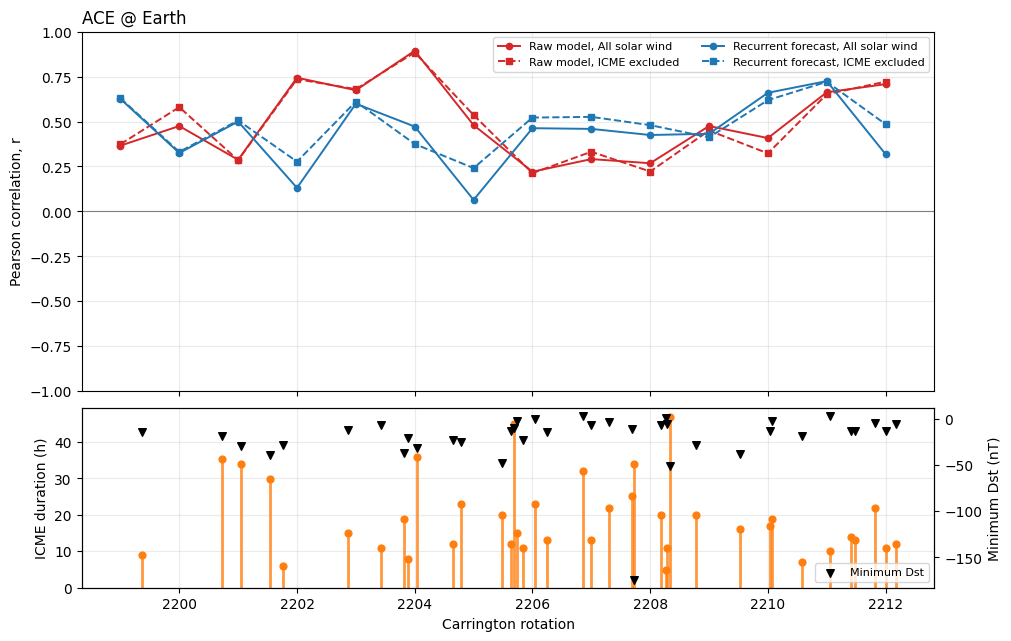

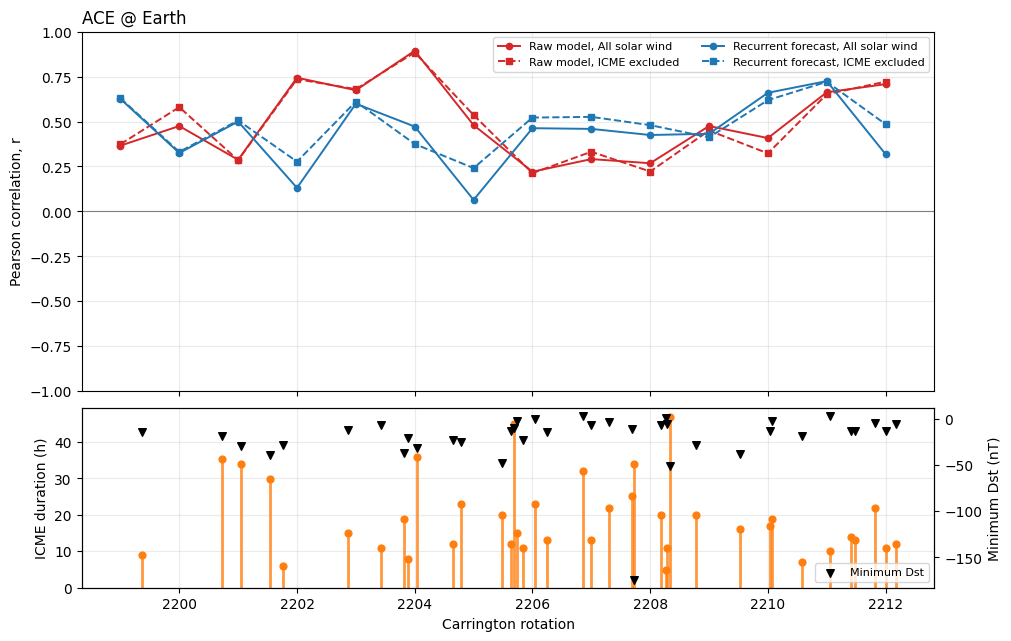

In [9]:
ace_figure = plot_cr_icme_figure(
    cr_stats=cr_stats,
    events=icme_events,
    sat=SAT_LABELS["ace_earth"],
)
ace_figure.savefig(ACE_FIGURE_PATH, dpi=300, bbox_inches="tight")
ace_figure


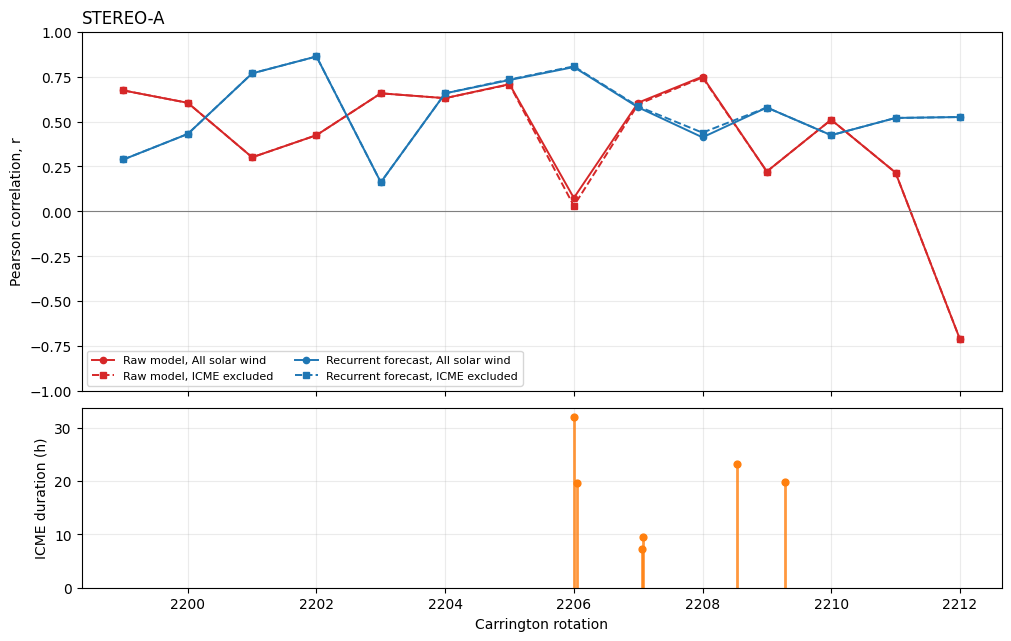

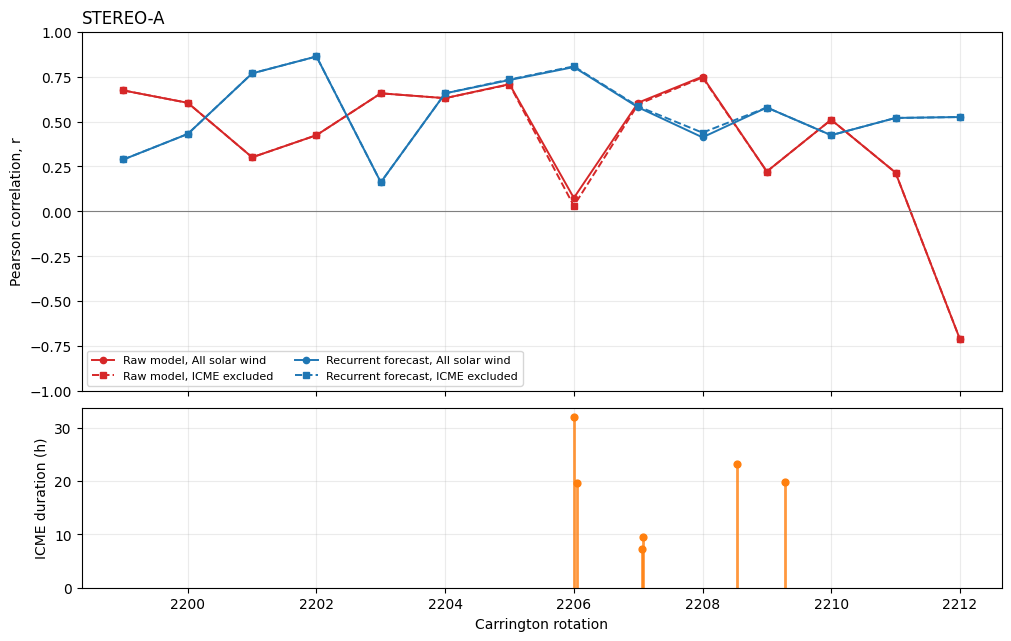

In [10]:
stereo_figure = plot_cr_icme_figure(
    cr_stats=cr_stats,
    events=icme_events,
    sat=SAT_LABELS["stereo_a"],
)
stereo_figure.savefig(STEREO_FIGURE_PATH, dpi=300, bbox_inches="tight")
stereo_figure


## Hourly workbook for Julia

Export the exact series used by the paper statistics. Missing observations remain blank, the ICME columns use the same exclusion masks as the statistics, and no ENLIL series are included.


In [ ]:
julia_report = build_hourly_report_frame(
    reproduction_frame=reproduction_frame,
    comparison_frames=comparison_frames,
    start_dt=START_DT,
    end_dt=END_DT,
)
write_report(julia_report, JULIA_REPORT_PATH)
julia_report


## Outputs


In [11]:
{
    "solar_wind_time_series": SW_TIME_SERIES_PATH,
    "julia_excel_report": JULIA_REPORT_PATH,
    "whole_period_stats": WHOLE_STATS_PATH,
    "per_cr_stats": CR_STATS_PATH,
    "icme_events": ICME_EVENTS_PATH,
    "ace_figure": ACE_FIGURE_PATH,
    "stereo_figure": STEREO_FIGURE_PATH,
}


{'solar_wind_time_series': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Time Series 20180101_0000-20190101_0000.pdf'),
 'whole_period_stats': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Paper Stats 20180101_0000-20190101_0000.csv'),
 'per_cr_stats': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Paper Per-CR Stats 20180101_0000-20190101_0000.csv'),
 'icme_events': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW ICME Events 20180101_0000-20190101_0000.csv'),
 'ace_figure': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Paper CR Correlation ACE 20180101_0000-20190101_0000.pdf'),
 'stereo_figure': PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/SW Paper CR Correlation STEREO-A 20180101_0000-20190101_0000.pdf')}